# SPX discretely monitored arithmetic Asian: what vanilla prices identify
**25 September 2026 · ATM call · five monitoring points · final maturity 18 December 2026**

The average uses today's spot and four future observations.

**How much does the observed SPX vanilla surface identify an arithmetic Asian value without specifying the underlying dynamics?**

European options constrain risk-neutral marginal distributions at individual maturities. An Asian payoff depends on the joint path across those maturities. Martingale optimal transport (MOT) searches over admissible couplings, subject to the quoted bid/ask prices and martingale constraints. Its lower and upper bounds measure the pricing ambiguity left by those restrictions; here they are computed on a finite price and integral grid.

Two comparisons guide the analysis:
- How much do intermediate-maturity vanilla surfaces narrow the identification interval?
- How large is Black–Scholes–Heston disagreement relative to that interval?

In [1]:
from pathlib import Path
import hashlib
import json
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import Image, Markdown, display

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
os.chdir(root)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

OBSERVATION_DATE = "2026-09-25"
RESULTS_DIR = root / "results/spx_mot" / OBSERVATION_DATE
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def load_json(filename):
    return json.loads((RESULTS_DIR / filename).read_text())


def show_figure(fig, filename, width=900):
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    display(Image(data=path.read_bytes(), width=width))
    plt.close(fig)


mot = load_json("mot_bounds.json")
bs = load_json("black_scholes_asian.json")
heston = load_json("heston_asian.json")
experiment = load_json("information_experiment.json")
convergence = pd.read_csv(RESULTS_DIR / "convergence.csv")
information = pd.read_csv(RESULTS_DIR / "information_experiment.csv")

## Contract and market inputs
The discretely monitored average includes today's spot and four expiry observations, with trapezoidal weights: $\bar S=\sum_k w_k S_{t_k}$ and $\sum_k w_k=1$.

Carry is the deterministic forward scaling inferred from put–call parity; dividing the asset level by carry removes that component so the normalized asset is a martingale under the pricing measure.

In [2]:
from robust_pricing.asian.types import Market
from scripts.run_spx_mot import build_market, load_processed_market_data
from benchmarks.black_scholes_asian import (
    calibration_quotes, black_scholes_prices, calibration_diagnostics,
)
from benchmarks.heston_asian import heston_prices, fourier_quadrature

# Verify that the saved runs used the same market inputs and contract.
data_dir = root / "data/processed/marketdata" / OBSERVATION_DATE
data_paths = [data_dir / "SPXW_clean.csv", data_dir / "term_structure.csv"]
path = RESULTS_DIR / "mot_bounds.json"
assert hashlib.sha256(path.read_bytes()).hexdigest() == experiment["input_sha256"][path.name]
assert experiment["baseline_reproduced"]

contract = experiment["contract"]
L = mot["solver_result"]["lower"]
U = mot["solver_result"]["upper"]
W = U - L

assert np.isfinite([L, U]).all() and 0 <= L <= U
full = information.set_index("name").loc["full", ["lower", "upper"]]
np.testing.assert_allclose(full.astype(float), [L, U], atol=1e-6, rtol=0)

for field in ("observation_date", "expirations", "spot", "asian_strike", "asian_kind"):
    assert mot[field] == contract[field]

for model in (bs, heston):
    for field in ("observation_date", "expirations", "asian_kind", "average_definition"):
        assert model[field] == contract[field]
    for field in ("spot", "asian_strike", "times", "carry", "discount", "terminal_discount"):
        np.testing.assert_allclose(model[field], contract[field], atol=1e-8, rtol=1e-8)

has_market_data = all(path.exists() for path in data_paths)

if has_market_data:
    for path in data_paths:
        assert hashlib.sha256(path.read_bytes()).hexdigest() == experiment["input_sha256"][path.name], path.name
    chain, term = load_processed_market_data()
    market = build_market(chain, term)
    for field in ("spot", "times", "carry", "discount"):
        np.testing.assert_allclose(getattr(market, field), contract[field], atol=1e-8, rtol=1e-8)
else:
    market = Market(spot=contract["spot"], times=np.array(contract["times"]),
                    carry=np.array(contract["carry"]), discount=np.array(contract["discount"]))

times = np.array(contract["times"])
dt = np.diff(times)

weights = np.r_[dt[0], dt[:-1] + dt[1:], dt[-1]] / (2 * times[-1])

np.testing.assert_allclose(weights.sum(), 1)
dates = pd.to_datetime([contract["observation_date"], *contract["expirations"]])
date_labels = dates.strftime("%d %b")
contract_table = pd.DataFrame({
    "Spot": [contract["spot"]],
    "Strike": [contract["asian_strike"]],
    "Expiry": [contract["expirations"][-1]],
    "Monitoring points": [len(times)],
    "Terminal discount": [contract["terminal_discount"]],
    "Contract check": ["PASS"],
})
display(contract_table.style.format({
    "Spot": "{:,.2f}", "Strike": "{:,.2f}", "Terminal discount": "{:.6f}",
}).hide(axis="index"))

Spot,Strike,Expiry,Monitoring points,Terminal discount,Contract check
"7,743.41","7,743.41",2026-12-18,5,0.989553,PASS


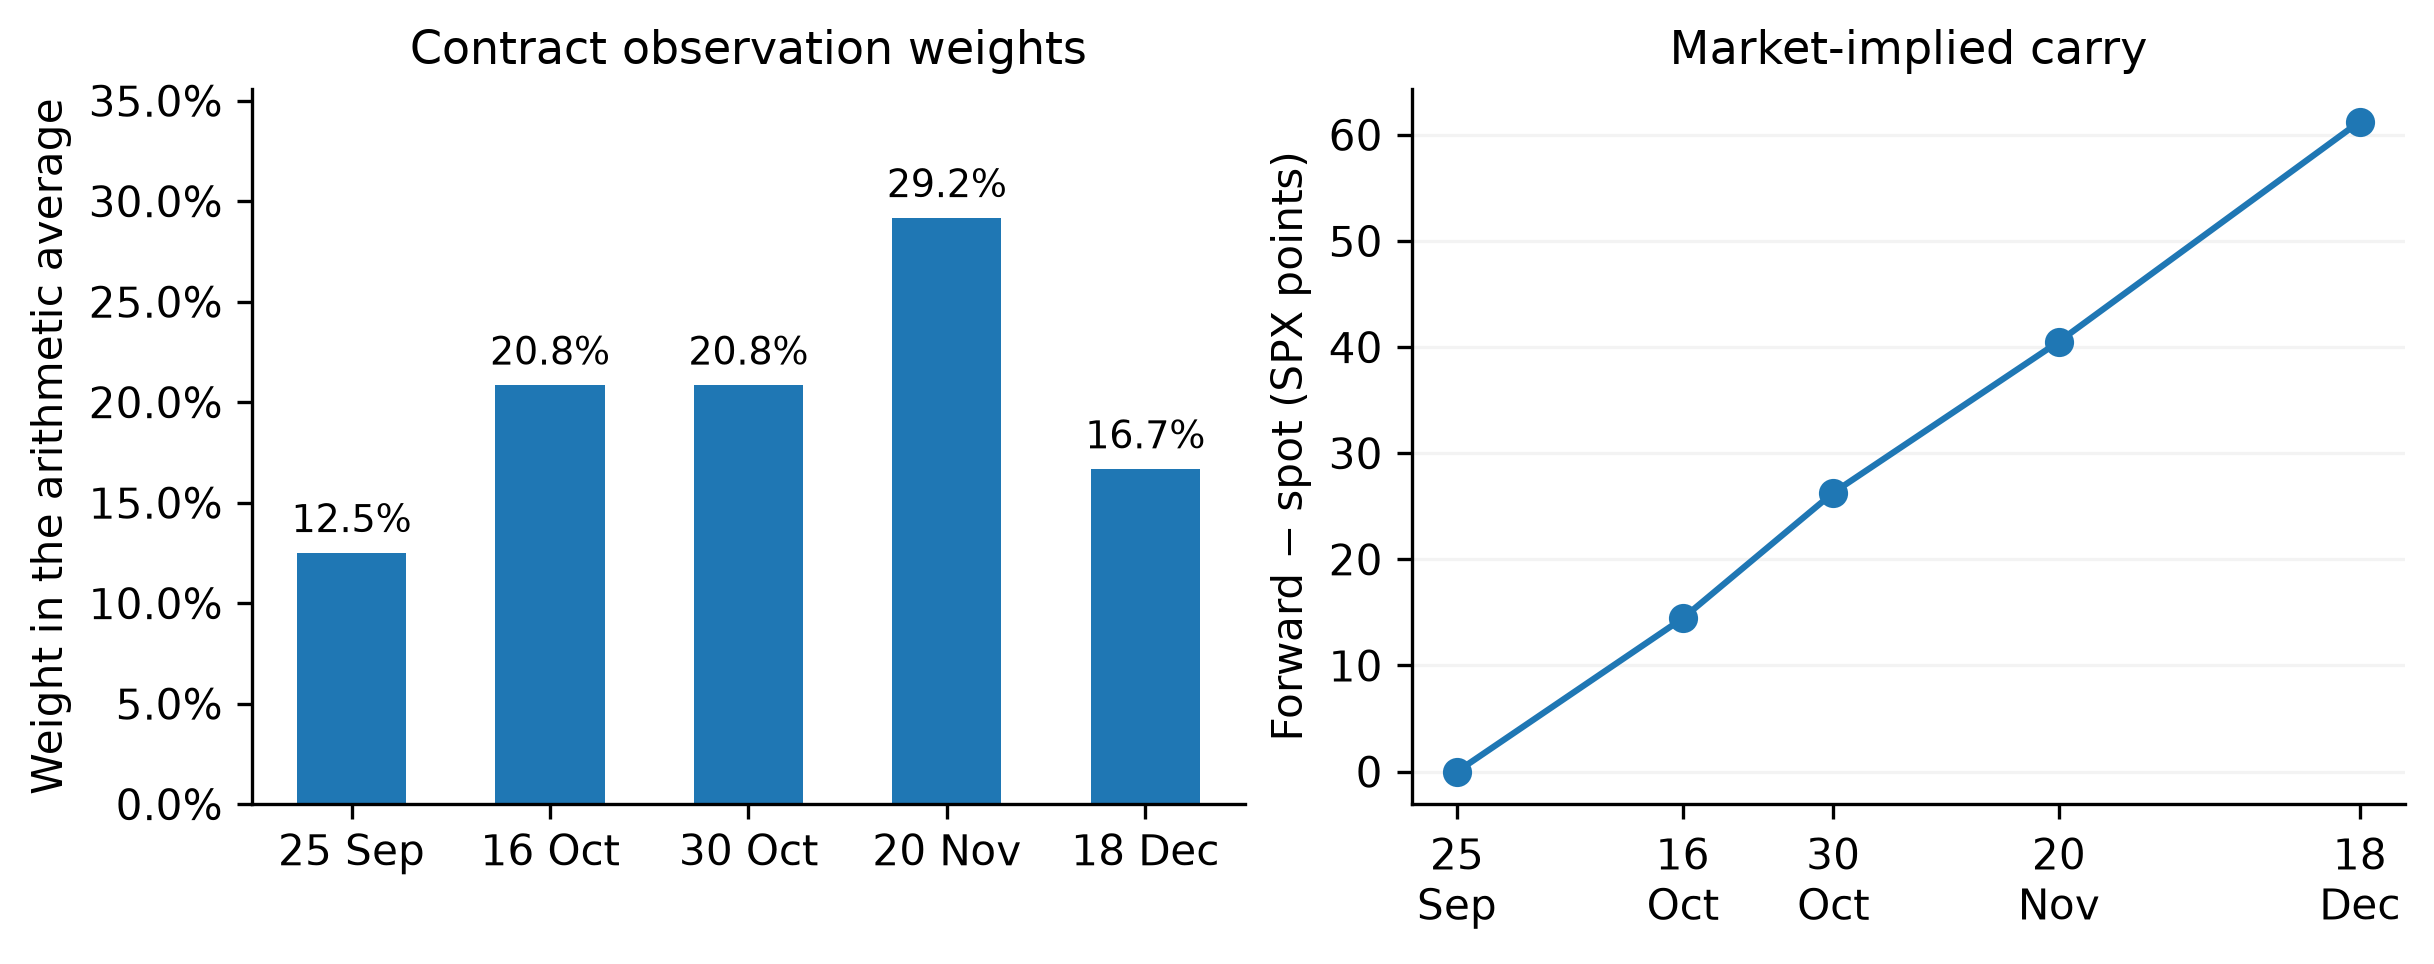

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.1), layout="constrained")
x = np.arange(len(times))
axes[0].bar(x, weights, width=.55)
axes[0].set_xticks(x, date_labels)
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_ylabel("Weight in the arithmetic average")
axes[0].set_title("Contract observation weights")
for i, weight in enumerate(weights):
    axes[0].annotate(f"{weight:.1%}", (i, weight), xytext=(0, 5),
                     textcoords="offset points", ha="center", fontsize=9)
axes[0].set_ylim(0, weights.max()*1.22)
forward = market.spot * market.carry / market.carry[0]
axes[1].plot(dates, forward-market.spot, marker="o")
axes[1].set_xticks(dates, dates.strftime("%d\n%b"))
axes[1].set_ylabel("Forward − spot (SPX points)")
axes[1].set_title("Market-implied carry")
axes[1].grid(axis="y", alpha=.15)
show_figure(fig, "contract_and_carry.png", width=780)

## Robust MOT valuation
The interval gives the range admitted by the vanilla bid/ask constraints and the discretized martingale formulation. $W=U-L$ is its identification width; $D=|V_{Heston}-V_{BS}|$ is benchmark disagreement. The markers include 95% Monte Carlo error bars.

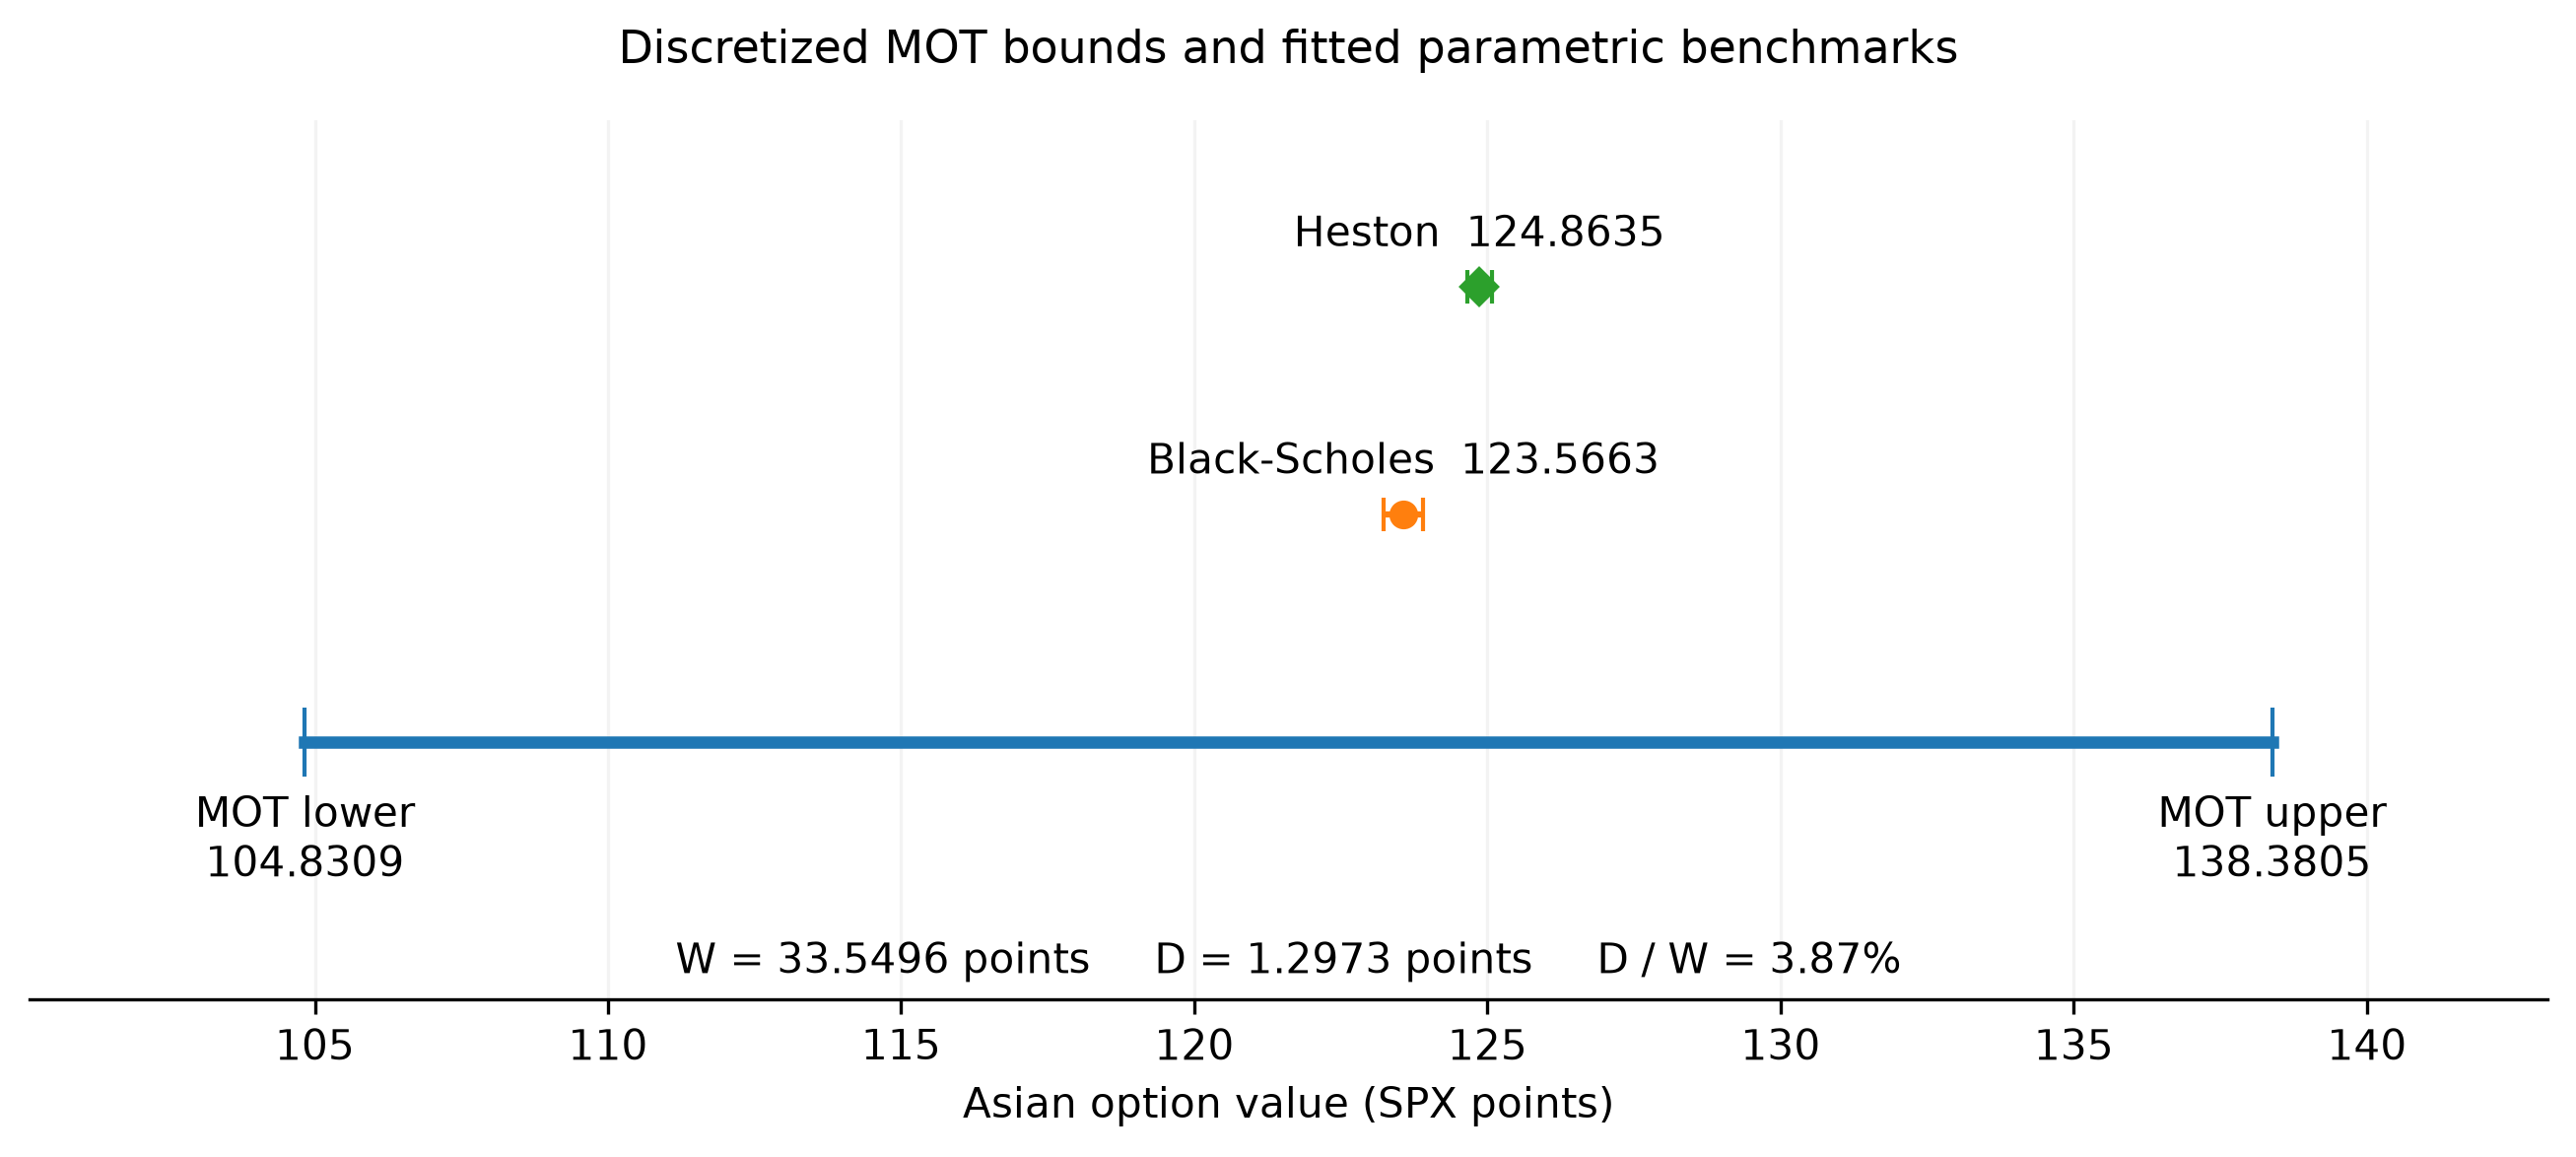

In [4]:
models = {"Black-Scholes": bs, "Heston": heston}
V_BS, V_Heston = bs["asian_price"], heston["asian_price"]
D = abs(V_Heston-V_BS)
R = D/W

for name, payload in models.items():
    value, se = payload["asian_price"], payload["standard_error"]
    low, high = payload["confidence_interval_95"]
    if not np.isfinite([value, se, low, high]).all() or se < 0 or not low <= value <= high:
        raise ValueError(f"Invalid {name} Monte Carlo results.")

fig, ax = plt.subplots(figsize=(8.6, 3.8), layout="constrained")
ax.plot([L, U], [0, 0], color="C0", linewidth=3, marker="|", markersize=17)
for value, label in ((L, "MOT lower"), (U, "MOT upper")):
    ax.annotate(f"{label}\n{value:.4f}", (value, 0), xytext=(0, -12),
                textcoords="offset points", ha="center", va="top", fontsize=10)
    
for (name, payload), y, color, marker in zip(models.items(), (.75, 1.5), ("C1", "C2"), ("o", "D")):
    value = payload["asian_price"]
    low, high = payload["confidence_interval_95"]
    ax.errorbar(value, y, xerr=[[value-low], [high-value]], fmt=marker,
                color=color, capsize=4, markersize=6)
    ax.annotate(f"{name}  {value:.4f}", (value, y), xytext=(0, 10),
                textcoords="offset points", ha="center")
    
ax.text(.5, .03, f"W = {W:.4f} points     D = {D:.4f} points     D / W = {R:.2%}",
        transform=ax.transAxes, ha="center", fontsize=10)

ax.set_title("Discretized MOT bounds and fitted parametric benchmarks", pad=14)
ax.set_xlabel("Asian option value (SPX points)")
ax.set_ylim(-.85, 2.05)
ax.set_xlim(L-.14*W, U+.14*W)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.grid(axis="x", alpha=.15)
show_figure(fig, "mot_vs_models.png")

## Parametric benchmark comparison
The benchmarks fit mid prices and do not reproduce every quote within bid/ask. Their location inside the interval does not establish feasibility in the MOT calibration set; $D/W$ is a descriptive comparison.

In [5]:
rows = [["MOT lower", L, np.nan, np.nan, np.nan, 0.0]]
for name, model in models.items():
    value = model["asian_price"]
    low, high = model["confidence_interval_95"]
    rows.append([name, value, model["standard_error"], low, high, (value - L) / W])
rows.append(["MOT upper", U, np.nan, np.nan, np.nan, 1.0])
valuation = pd.DataFrame(rows, columns=["Model", "Value", "MC SE", "MC lower", "MC upper", "Position"])
display(valuation.style.format({
    "Value": "{:.4f}", "MC SE": "{:.4f}", "MC lower": "{:.4f}",
    "MC upper": "{:.4f}", "Position": "{:.3f}",
}, na_rep="—").hide(axis="index"))

display(Markdown(f"The two model values differ by **{D:.2f} points**, or **{R:.2%}** of the **{W:.2f}-point** robust width."))

Model,Value,MC SE,MC lower,MC upper,Position
MOT lower,104.8309,—,—,—,0.000
Black-Scholes,123.5663,0.1700,123.2331,123.8994,0.558
Heston,124.8635,0.1082,124.6515,125.0756,0.597
MOT upper,138.3805,—,—,—,1.000


The two model values differ by **1.30 points**, or **3.87%** of the **33.55-point** robust width.

## Value of intermediate-maturity information
The contract and numerical grid are fixed while the available vanilla maturity set varies. This counterfactual measures the contribution of intermediate vanilla surfaces to price identification. All five Asian observations, and the full-chain forward and discount curves, remain fixed.

In [6]:
order = ["full", "reduced", "final_only"]
information = information.set_index("name").reindex(order)
assert information["status"].eq("success").all()
assert information[["lower", "upper"]].notna().all().all()
for field, value in experiment["grid"].items():
    np.testing.assert_allclose(information[field], value, rtol=0, atol=1e-9)
information["width"] = information["upper"] - information["lower"]
quote_times = {name: set(json.loads(row.vanilla_maturities)) for name, row in information.iterrows()}
assert quote_times["full"] > quote_times["reduced"] > quote_times["final_only"]
assert (np.diff(information["lower"]) <= 1e-6).all()
assert (np.diff(information["upper"]) >= -1e-6).all()
labels = {"full": "All four maturities", "reduced": "30 Oct + 18 Dec", "final_only": "18 Dec only"}
info_table = information[["n_maturities", "n_quotes", "lower", "upper", "width"]].copy()
info_table.index = [labels[name] for name in order]
info_table.index.name = "Vanilla information"
display(info_table.iloc[::-1].style.format({"lower": "{:.4f}", "upper": "{:.4f}", "width": "{:.4f}"}))

,n_maturities,n_quotes,lower,upper,width
Vanilla information,,,,,
18 Dec only,1,80,46.9597,193.4240,146.4644
30 Oct + 18 Dec,2,160,93.4814,158.1742,64.6927
All four maturities,4,320,104.8309,138.3805,33.5496


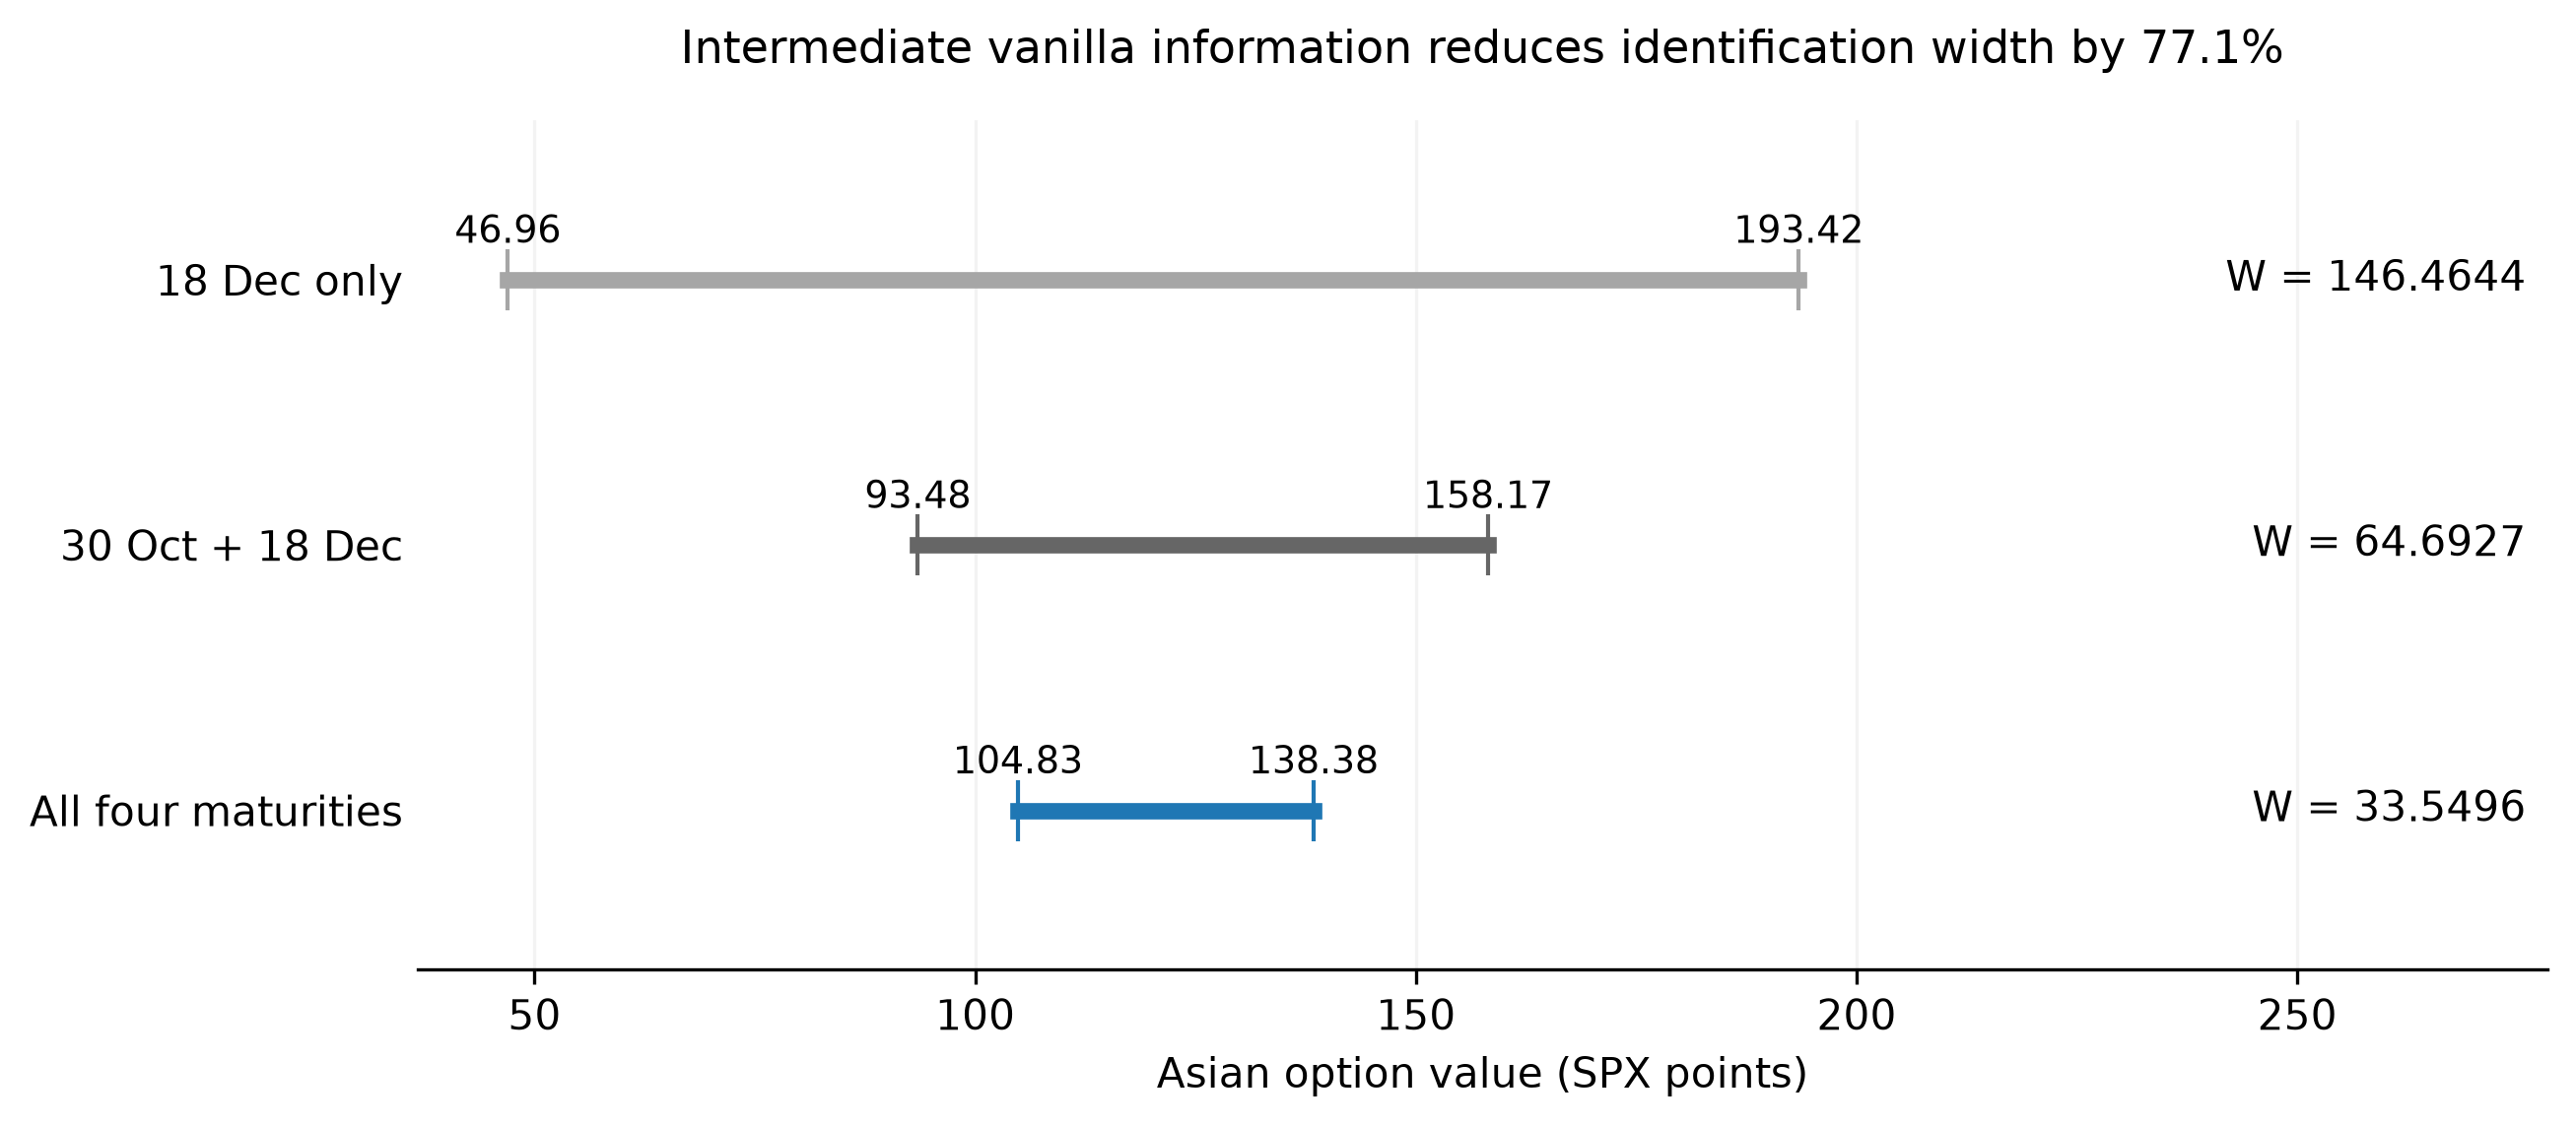

In [7]:
final_width = information.loc["final_only", "width"]
width_reduction = 1-information.loc["full", "width"]/final_width
fig, ax = plt.subplots(figsize=(8.6, 3.7), layout="constrained")
for y, name, color in zip(range(3), ("final_only", "reduced", "full"), ("0.65", "0.4", "C0")):
    row = information.loc[name]
    ax.plot([row.lower, row.upper], [y, y], color=color, linewidth=4, marker="|", markersize=15)
    ax.annotate(f"{row.lower:.2f}", (row.lower, y), xytext=(0, 9),
                textcoords="offset points", ha="center", fontsize=9)
    ax.annotate(f"{row.upper:.2f}", (row.upper, y), xytext=(0, 9),
                textcoords="offset points", ha="center", fontsize=9)
    ax.text(.99, y, f"W = {row.width:.4f}", transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontsize=10)
ax.set_yticks(range(3), [labels[name] for name in ("final_only", "reduced", "full")])
ax.set_ylim(2.6, -.6)
ax.set_xlim(information["lower"].min()-.07*final_width,
            information["upper"].max()+.58*final_width)
ax.set_xlabel("Asian option value (SPX points)")
ax.set_title(f"Intermediate vanilla information reduces identification width by {width_reduction:.1%}", pad=14)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", alpha=.15)
show_figure(fig, "information_sets.png")

## Numerical robustness
Selected local refinements change either the price-state or integral-state resolution. The table and plot compare them with the saved baseline; they do not establish convergence to a continuous-state MOT problem.

Grid,Lower,Upper,Width,Δ width
50 × 21,104.8309,138.3805,33.5496,+0.0000
50 × 25,104.4943,138.2440,33.7497,+0.2001
52 × 21,104.8466,138.3387,33.4921,-0.0575


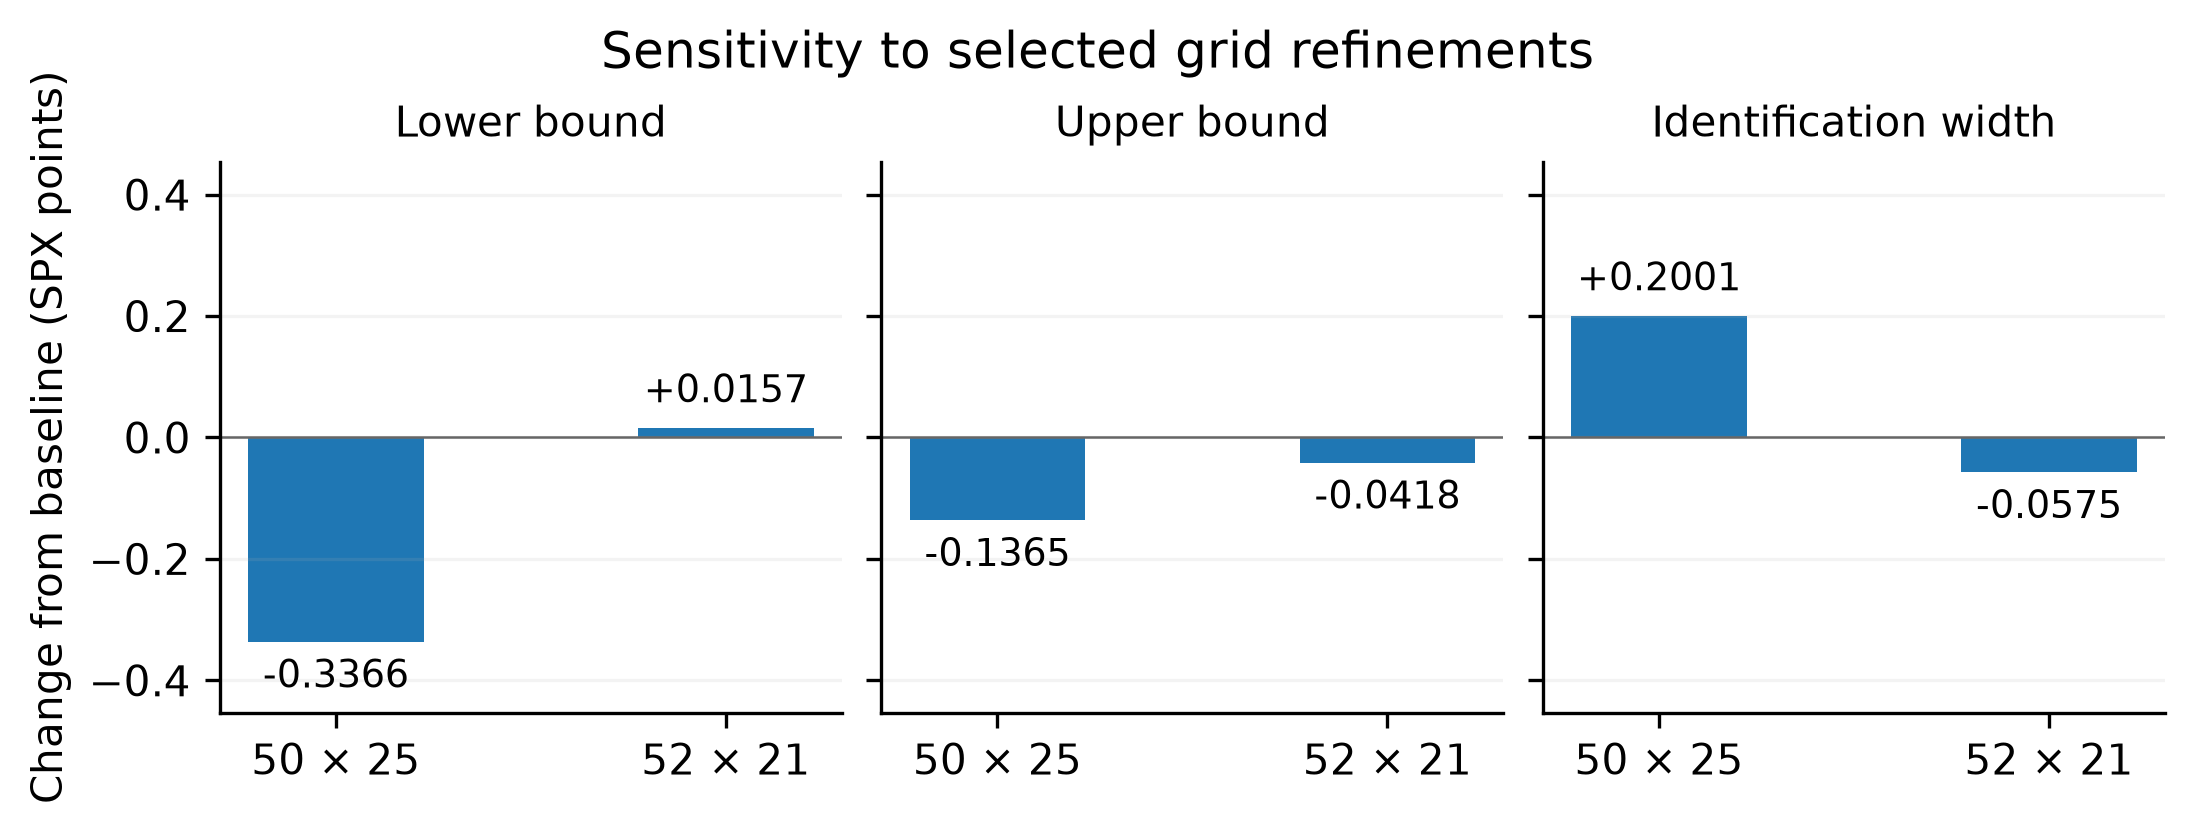

Largest width change: **0.2001 points (0.60%)**.

In [8]:
assert convergence["status"].eq("success").all()
stability = convergence.copy()
stability["width"] = stability["upper"]-stability["lower"]
for field, baseline in (("lower", L), ("upper", U), ("width", W)):
    stability[f"delta_{field}"] = stability[field]-baseline
assert np.isfinite(stability[["lower", "upper", "width"]]).all().all()
stability["Grid"] = [f"{int(nx)} × {int(na)}" for nx, na in zip(stability.n_x, stability.n_integral)]
display(stability[["Grid", "lower", "upper", "width", "delta_width"]].rename(
    columns={"lower": "Lower", "upper": "Upper", "width": "Width",
             "delta_width": "Δ width"}).style.format(
    {"Lower": "{:.4f}", "Upper": "{:.4f}", "Width": "{:.4f}",
     "Δ width": "{:+.4f}"}).hide(axis="index"))

refinements = stability.loc[~stability["name"].eq("baseline")]
plot_limit = max(1.35*np.abs(refinements[["delta_lower", "delta_upper", "delta_width"]].to_numpy()).max(), .01)
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.6), sharey=True, layout="constrained")

for ax, field, title in zip(axes, ("lower", "upper", "width"), ("Lower bound", "Upper bound", "Identification width")):
    bars = ax.bar(range(len(refinements)), refinements[f"delta_{field}"], width=.45)
    ax.axhline(0, color="0.4", linewidth=.6)
    ax.bar_label(bars, fmt="%+.4f", padding=4, fontsize=9)
    ax.set_xticks(range(len(refinements)), refinements["Grid"])
    ax.set_title(title, fontsize=10)
    ax.set_ylim(-plot_limit, plot_limit)
    ax.grid(axis="y", alpha=.15)

axes[0].set_ylabel("Change from baseline (SPX points)")
fig.suptitle("Sensitivity to selected grid refinements", fontsize=12)
show_figure(fig, "numerical_stability.png", width=760)
max_width_change = stability["delta_width"].abs().max()
display(Markdown(f"Largest width change: **{max_width_change:.4f} points ({max_width_change / W:.2%})**."))

## Supporting model-fit diagnostics
Both benchmarks were fitted to the same OTM-side mid quotes at each strike and maturity, minimizing relative price residuals. Below, unweighted RMSE measures fit in SPX points. With local quote data, prices are evaluated at the saved parameters and checked against the saved diagnostics. Without vendor data, the table and figure use those diagnostics directly. Calibration is not rerun.

Parameters at calibration bounds should be read as fit constraints, rather than economic estimates.

Model,RMSE (points),Outside bid/ask,Quotes fitted
Black-Scholes,11.2344,156,160
Heston,1.3402,131,160


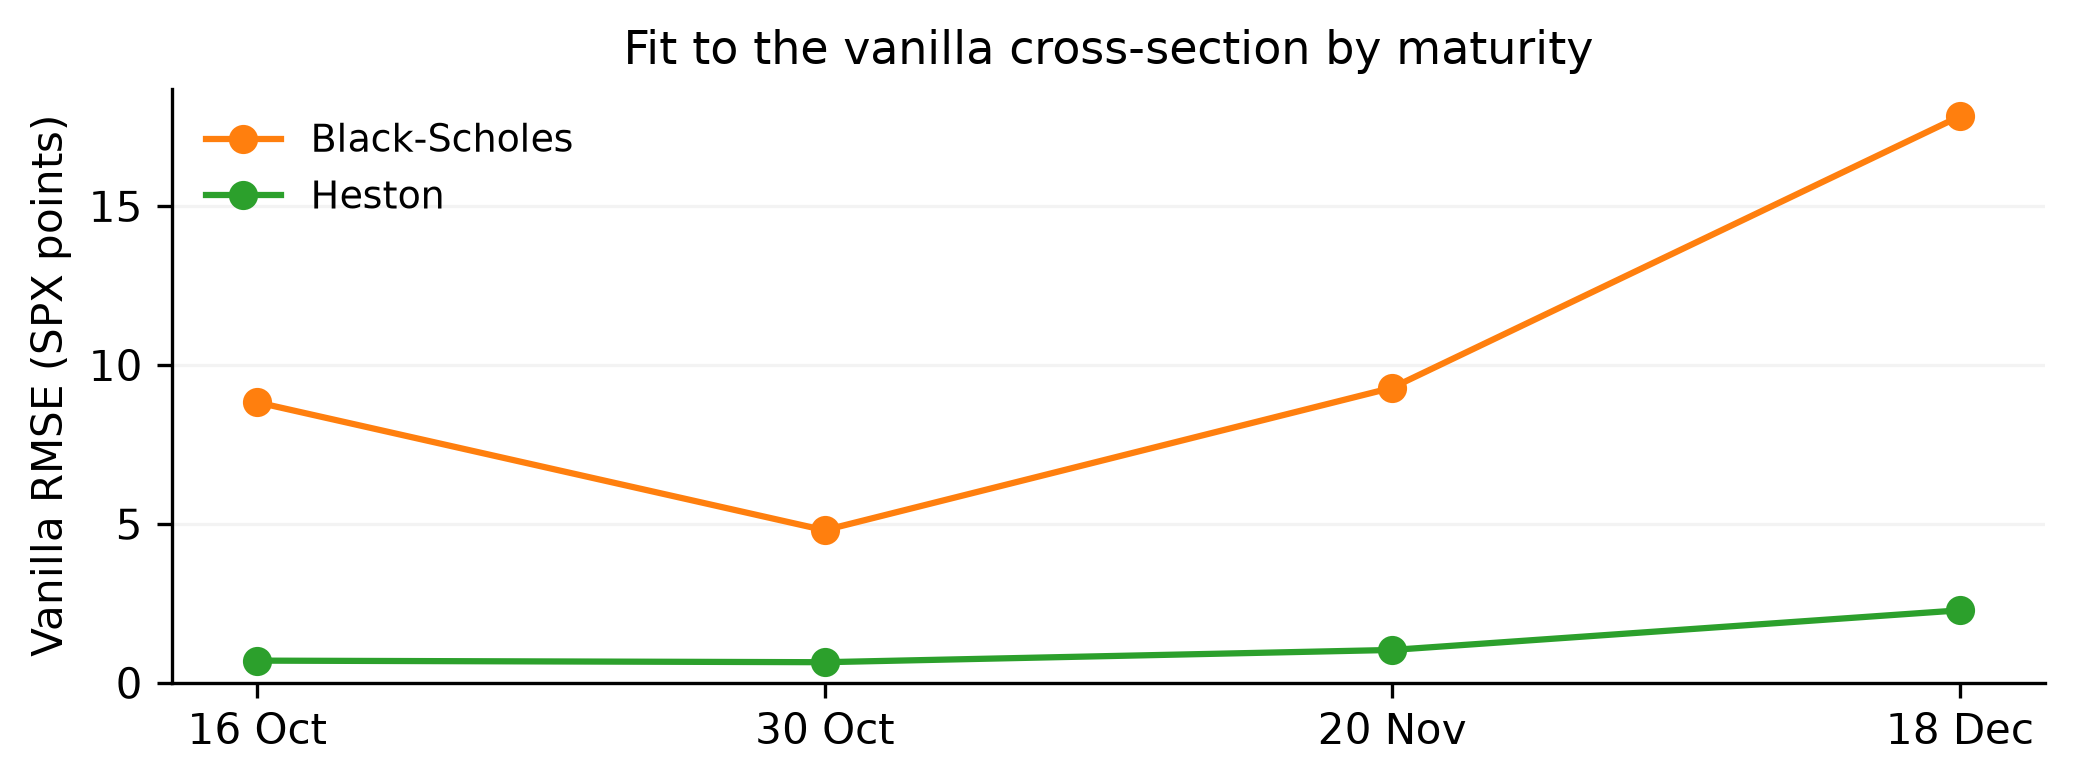

In [9]:
if has_market_data:
    quotes = calibration_quotes(market)
    bs_prices = black_scholes_prices(
        sigma=bs["parameters"]["sigma"],
        times=quotes["times"],
        strikes=quotes["strikes"],
        forwards=quotes["forwards"],
        discounts=quotes["discounts"],
        is_call=quotes["is_call"],
    )
    h_prices = heston_prices(heston["parameters"], quotes, fourier_quadrature(512, 1024))
    fits = {"Black-Scholes": bs_prices, "Heston": h_prices}
    fit_rows = []
    for name, prices in fits.items():
        diagnostic = calibration_diagnostics(quotes, prices)
        np.testing.assert_allclose(diagnostic["rmse"], models[name]["calibration"]["rmse"], atol=1e-6, rtol=0)
        fit_rows.append({"Model": name, "RMSE (points)": diagnostic["rmse"],
                         "Outside bid/ask": diagnostic["quotes_outside_bid_ask"],
                         "Quotes fitted": diagnostic["n_quotes"]})
    display(pd.DataFrame(fit_rows).style.format({"RMSE (points)": "{:.4f}"}).hide(axis="index"))


    fig, ax = plt.subplots(figsize=(6.8, 2.5), layout="constrained")
    for (name, prices), color in zip(fits.items(), ("C1", "C2")):
        errors = prices-quotes["mid"]
        rmse_by_maturity = [np.sqrt(np.mean(errors[quotes["times"] == t]**2)) for t in times[1:]]
        ax.plot(np.arange(len(rmse_by_maturity)), rmse_by_maturity, marker="o", color=color, label=name)
    ax.set_xticks(range(len(times)-1), date_labels[1:])
    ax.set_ylim(bottom=0)
    ax.set_ylabel("Vanilla RMSE (SPX points)")
    ax.set_title("Fit to the vanilla cross-section by maturity")
    ax.legend(frameon=False, fontsize=9)
    ax.grid(axis="y", alpha=.15)
    show_figure(fig, "vanilla_fit.png", width=720)
else:
    fit_rows = []
    for name, payload in models.items():
        diagnostic = payload["calibration"]
        fit_rows.append({"Model": name, "RMSE (points)": diagnostic["rmse"],
                         "Outside bid/ask": diagnostic["quotes_outside_bid_ask"],
                         "Quotes fitted": diagnostic["n_quotes"]})
    display(pd.DataFrame(fit_rows).style.format({"RMSE (points)": "{:.4f}"}).hide(axis="index"))
    display(Image(data=(FIGURES_DIR / "vanilla_fit.png").read_bytes(), width=720))

In [10]:
bound_parameters = heston["calibration"]["parameters_at_bounds"]
if bound_parameters:
    display(pd.DataFrame({"Heston parameters at bounds": bound_parameters}))

,Heston parameters at bounds
0,kappa
1,rho


## Historical robustness
The detailed 25 September analysis is one market snapshot; the panel below solves a standardized ATM Asian call using archived 30/60/90/120-DTE buckets once per month. Each date is selected mechanically as the latest snapshot with usable data and a successful fixed-grid solve, without reference to its price interval. These monitoring dates differ from the flagship contract, so cross-date comparisons use widths normalized by spot.

In [11]:
historical_path = root / "results/spx_mot/historical_panel.csv"
historical = pd.read_csv(historical_path).sort_values("observation_date")
historical_metadata = json.loads(historical_path.with_name("historical_panel_metadata.json").read_text())
settings = historical_metadata["settings"]
assert not historical.empty
assert historical["month"].is_unique
assert historical["status"].eq("success").all()
assert settings["target_dtes"] == [30, 60, 90, 120]
for field in ("n_x", "n_integral"):
    np.testing.assert_array_equal(historical[field], np.full(len(historical), settings[field]))
np.testing.assert_allclose(historical["strike"], historical["spot"], rtol=0, atol=0)
np.testing.assert_allclose(historical["width"], historical["upper"] - historical["lower"])
np.testing.assert_allclose(historical["width_over_spot"], historical["width"] / historical["spot"])
assert np.isfinite(historical[["spot", "lower", "upper", "width_over_spot"]]).all().all()
assert historical["width"].gt(0).all()
assert historical.set_index("month")["observation_date"].to_dict() == historical_metadata["selected_dates"]
residual_columns = ["max_equality_residual_lower", "max_equality_residual_upper",
                    "max_inequality_violation_lower", "max_inequality_violation_upper"]
assert historical[residual_columns].notna().all().all()
assert historical[residual_columns].le(settings["residual_tolerance"]).all().all()

historical_table = historical[["observation_date", "spot", "lower", "upper", "width", "width_over_spot"]].rename(
    columns={"observation_date": "Date", "spot": "Spot", "lower": "MOT lower",
             "upper": "MOT upper", "width": "Width", "width_over_spot": "Width / Spot"})
display(historical_table.style.format({"Spot": "{:,.2f}", "MOT lower": "{:.2f}",
    "MOT upper": "{:.2f}", "Width": "{:.2f}", "Width / Spot": "{:.3%}"}).hide(axis="index"))

normalized_widths = historical["width_over_spot"]
historical_stats = {"Snapshots": len(historical), "Mean": normalized_widths.mean(),
                    "Median": normalized_widths.median(), "Min": normalized_widths.min(),
                    "Max": normalized_widths.max(), "Std. dev.": normalized_widths.std(ddof=1)}
display(pd.DataFrame([historical_stats]).style.format(
    {key: "{:.3%}" for key in historical_stats if key != "Snapshots"}, na_rep="—").hide(axis="index"))
skipped_months = historical_metadata["unusable_months"]
if skipped_months:
    display(pd.Series(skipped_months, name="Unusable months"))

Date,Spot,MOT lower,MOT upper,Width,Width / Spot
2026-01-30,"6,939.03",130.65,166.35,35.70,0.514%
2026-02-27,"6,878.88",146.31,179.51,33.21,0.483%
2026-03-10,"6,781.48",168.58,203.60,35.02,0.516%
2026-04-28,"7,138.80",139.64,175.91,36.27,0.508%
2026-05-29,"7,580.06",140.71,182.27,41.56,0.548%
2026-06-30,"7,499.22",141.63,180.90,39.27,0.524%
2026-07-10,"7,575.39",128.85,166.72,37.87,0.500%
2026-08-28,"7,711.76",133.70,172.54,38.84,0.504%
2026-09-25,"7,743.41",140.53,180.56,40.03,0.517%


Snapshots,Mean,Median,Min,Max,Std. dev.
9,0.513%,0.514%,0.483%,0.548%,0.018%


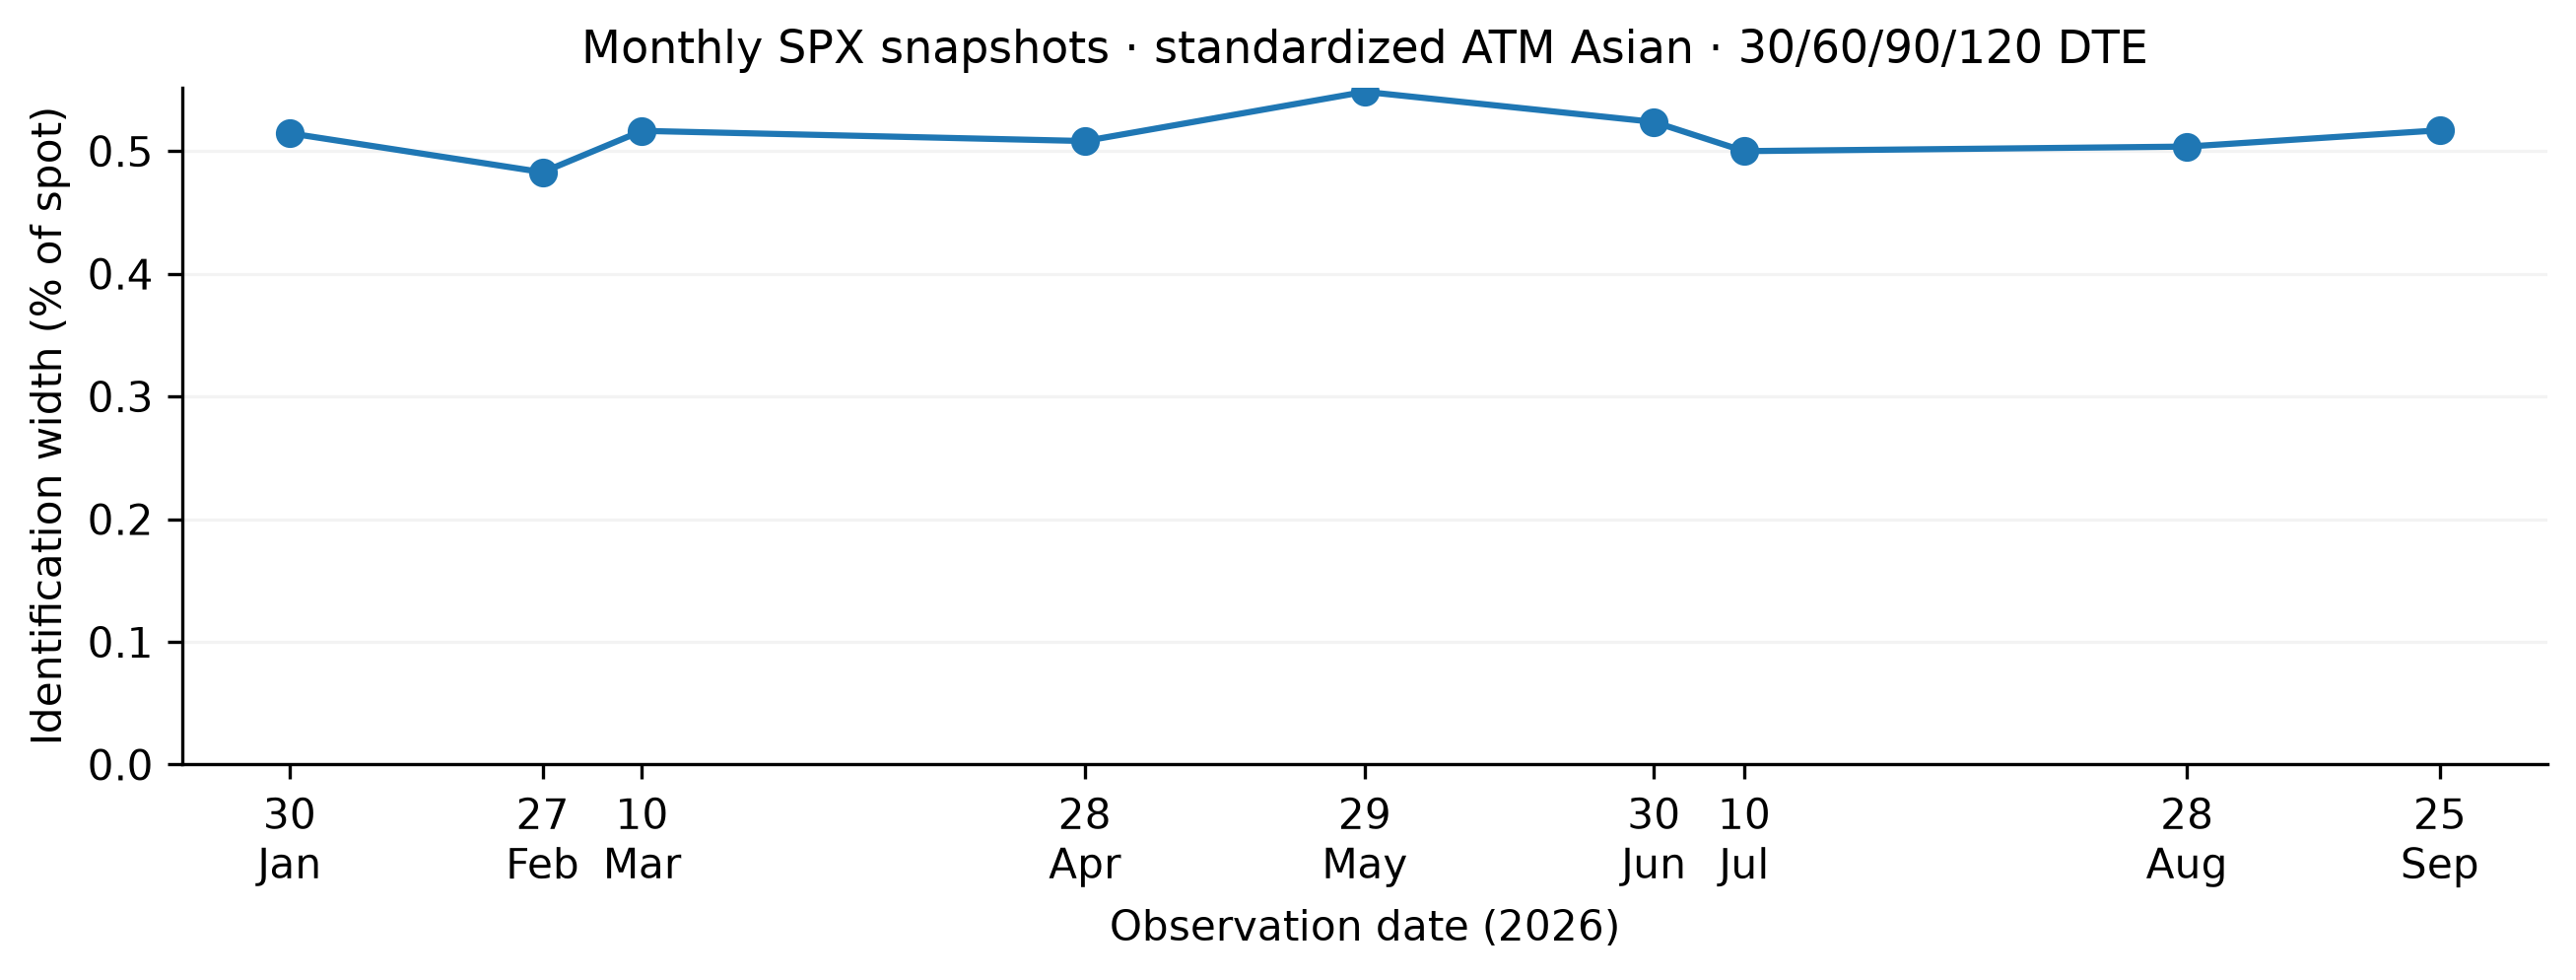

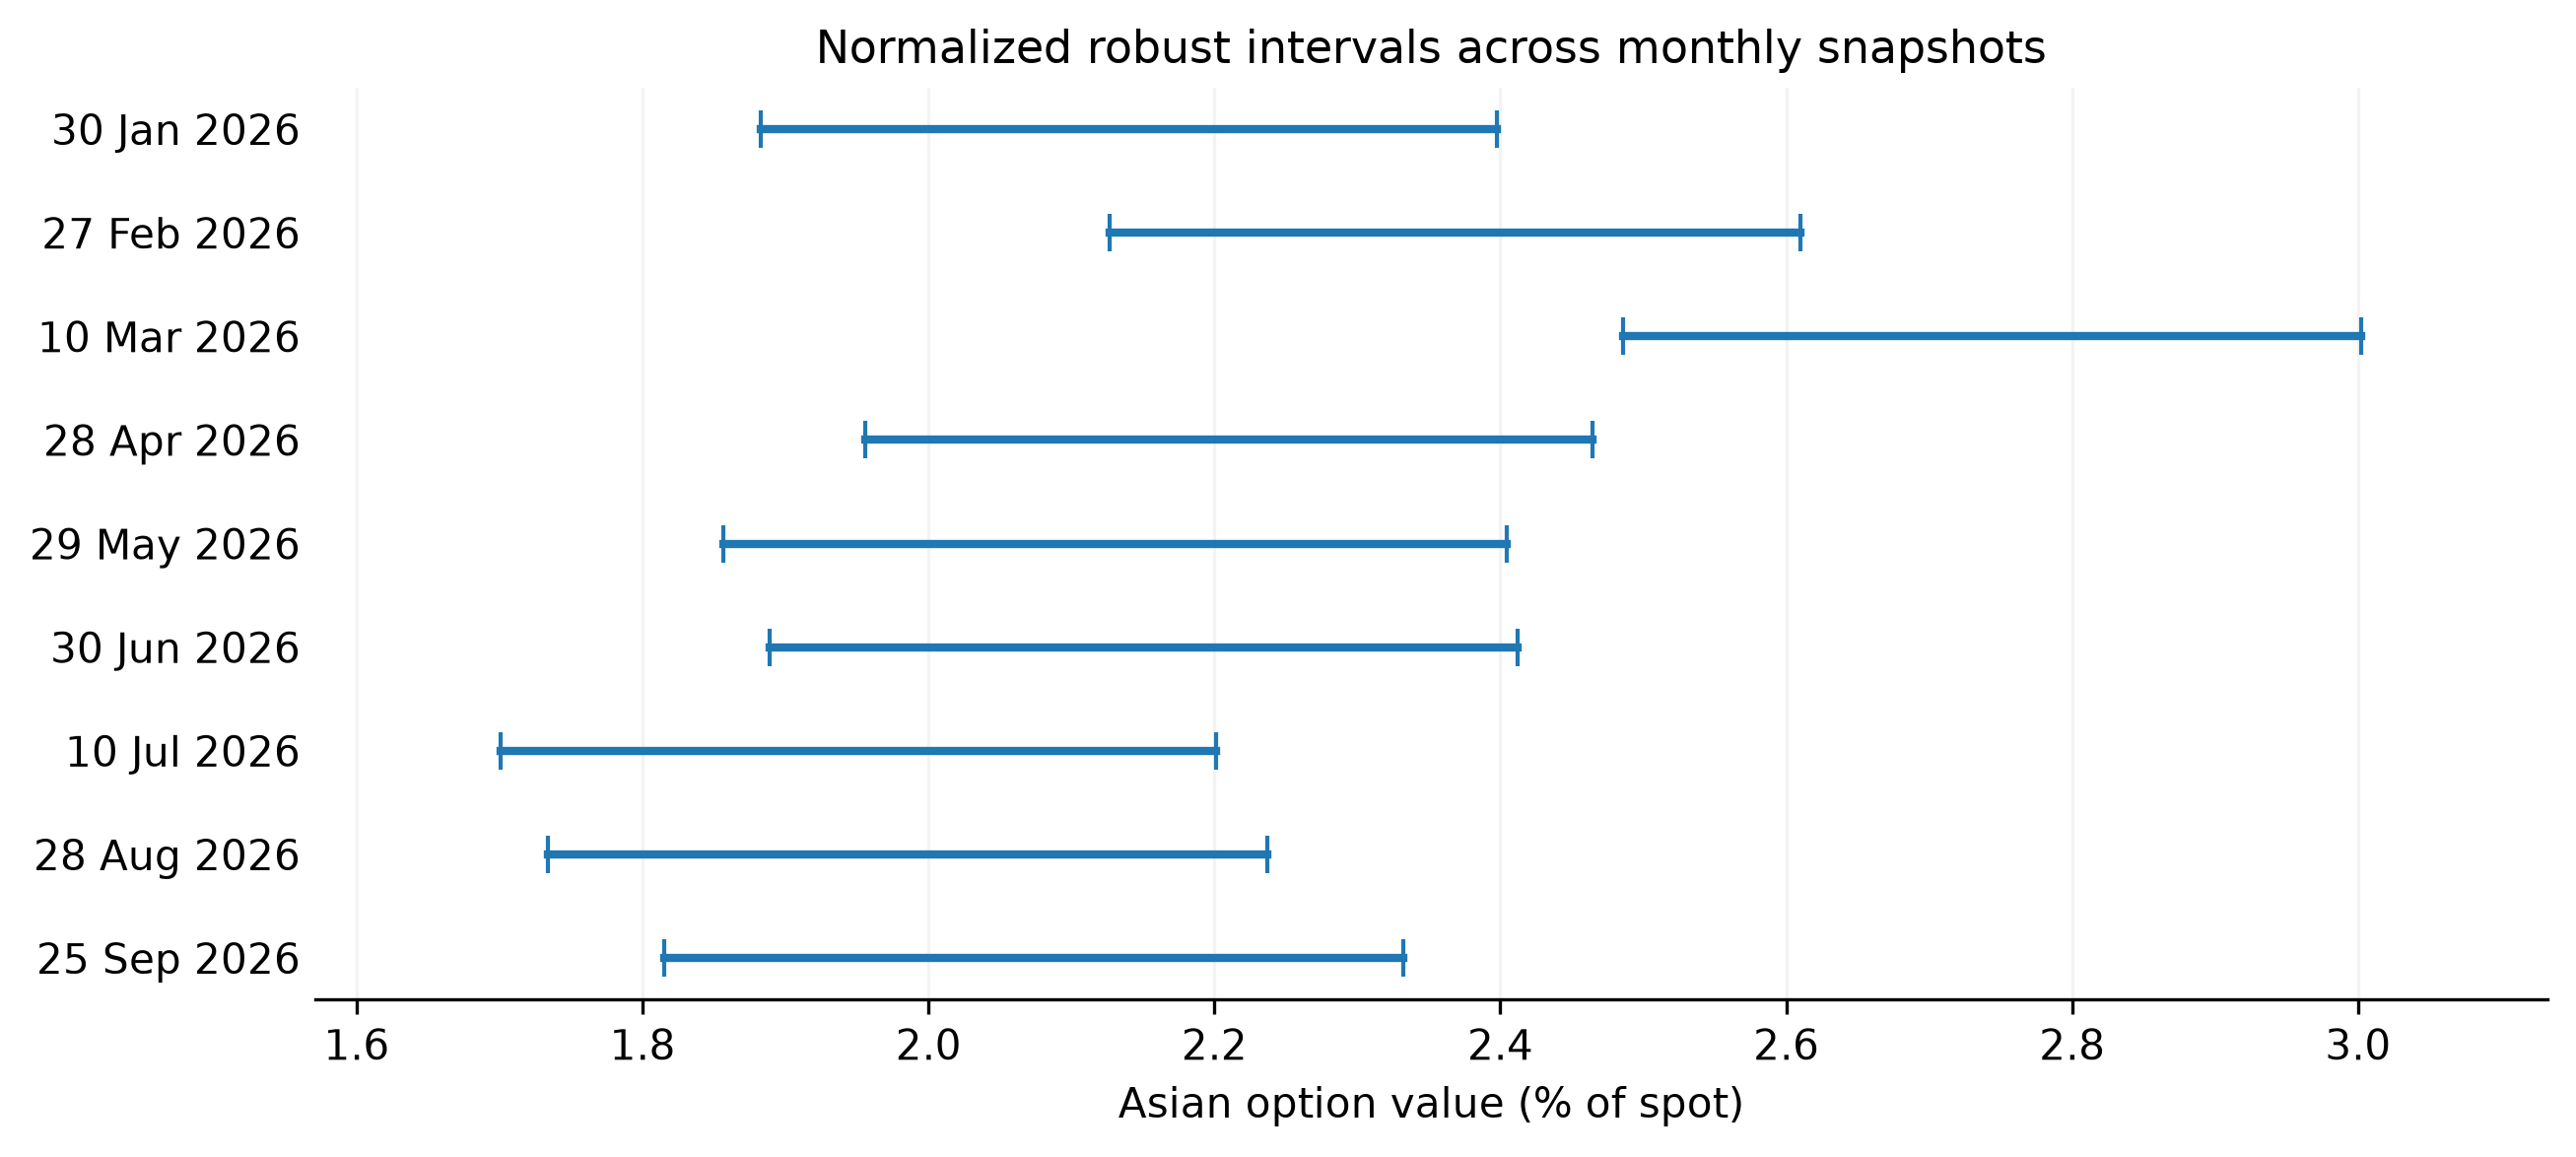

In [12]:
historical_dates = pd.to_datetime(historical["observation_date"])
fig, ax = plt.subplots(figsize=(8.6, 3.2), layout="constrained")
ax.plot(historical_dates, 100*normalized_widths, marker="o", linewidth=1.5)
ax.set_xticks(historical_dates, historical_dates.dt.strftime("%d\n%b"))
ax.set_ylim(bottom=0)
ax.set_ylabel("Identification width (% of spot)")
ax.set_xlabel("Observation date (2026)")
ax.set_title("Monthly SPX snapshots · standardized ATM Asian · 30/60/90/120 DTE")
ax.grid(axis="y", alpha=.15)
show_figure(fig, "historical_identification_width.png")

fig, ax = plt.subplots(figsize=(8.6, 3.8), layout="constrained")
for y, row in enumerate(historical.itertuples()):
    ax.plot([100*row.lower_over_spot, 100*row.upper_over_spot], [y, y],
            color="C0", linewidth=2, marker="|", markersize=9)
ax.set_yticks(range(len(historical)), historical_dates.dt.strftime("%d %b %Y"))
ax.invert_yaxis()
interval_min = 100*historical["lower_over_spot"].min()
interval_max = 100*historical["upper_over_spot"].max()
margin = .1*(interval_max-interval_min)
ax.set_xlim(interval_min-margin, interval_max+margin)
ax.set_xlabel("Asian option value (% of spot)")
ax.set_title("Normalized robust intervals across monthly snapshots")
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", alpha=.15)
show_figure(fig, "historical_normalized_intervals.png")

## Findings

In [13]:
display(Markdown(f"""
**25 September case study**

1. The grid-based MOT bounds are **{L:.4f}–{U:.4f}** points, with width **{W:.4f}**.
2. Intermediate vanilla surfaces reduce the width by **{width_reduction:.1%}** relative to terminal information alone.
3. Black–Scholes and Heston differ by **{D:.4f}** points: **{R:.2%}** of the robust width.
4. The largest width change in the local grid checks is **{max_width_change:.4f}** points (**{max_width_change / W:.2%}**).

**Historical panel**

All **{historical_stats['Snapshots']}** selected monthly snapshots retain a positive interval.
Widths range from **{historical_stats['Min']:.3%}** to **{historical_stats['Max']:.3%}** of spot
(median **{historical_stats['Median']:.3%}**), compared with **{W / market.spot:.3%}** in the flagship study.
The contracts and quote sets differ, so this is a descriptive comparison.

The bounds use finite grids. Monte Carlo intervals cover sampling error, excluding calibration,
model, and discretization error. The historical results describe snapshots that passed the data
and fixed-grid checks.
"""))

summary = {
    "mot_lower": L, "mot_upper": U, "mot_width": W,
    "bs_price": V_BS, "bs_standard_error": bs["standard_error"],
    "heston_price": V_Heston, "heston_standard_error": heston["standard_error"],
    "model_disagreement": D, "relative_model_disagreement": R,
    "bs_position_in_interval": (V_BS-L)/W,
    "heston_position_in_interval": (V_Heston-L)/W,
    "width_full": information.loc["full", "width"],
    "width_reduced": information.loc["reduced", "width"],
    "width_final_only": information.loc["final_only", "width"],
}
summary = {key: float(value) for key, value in summary.items()}
(RESULTS_DIR / "final_summary.json").write_text(json.dumps(summary, indent=2, allow_nan=False)+"\n", encoding="utf-8")
pd.DataFrame([summary]).to_csv(RESULTS_DIR / "final_summary.csv", index=False, float_format="%.10f")


**25 September case study**

1. The grid-based MOT bounds are **104.8309–138.3805** points, with width **33.5496**.
2. Intermediate vanilla surfaces reduce the width by **77.1%** relative to terminal information alone.
3. Black–Scholes and Heston differ by **1.2973** points: **3.87%** of the robust width.
4. The largest width change in the local grid checks is **0.2001** points (**0.60%**).

**Historical panel**

All **9** selected monthly snapshots retain a positive interval.
Widths range from **0.483%** to **0.548%** of spot
(median **0.514%**), compared with **0.433%** in the flagship study.
The contracts and quote sets differ, so this is a descriptive comparison.

The bounds use finite grids. Monte Carlo intervals cover sampling error, excluding calibration,
model, and discretization error. The historical results describe snapshots that passed the data
and fixed-grid checks.


## References
Black, F. and Scholes, M. (1973). *The Pricing of Options and Corporate Liabilities*. Journal of Political Economy, 81(3), 637–654.

Heston, S. L. (1993). *A Closed-Form Solution for Options with Stochastic Volatility with Applications to Bond and Currency Options*. Review of Financial Studies, 6(2), 327–343.

Beiglböck, M., Henry-Labordère, P. and Penkner, F. (2013). [*Model-independent bounds for option prices—a mass transport approach*](https://arxiv.org/abs/1106.5929). Finance and Stochastics, 17, 477–501.